In [8]:
import pandas as pd
import numpy as np

In [9]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


In [10]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008



Testing with EUCLIDEAN distance
MSE:  0.5112
RMSE: 0.7150
MAE:  0.5842
R²:   0.4525

Testing with MANHATTAN distance
MSE:  0.4995
RMSE: 0.7067
MAE:  0.5841
R²:   0.4651

Testing with MINKOWSKI distance
MSE:  0.5112
RMSE: 0.7150
MAE:  0.5842
R²:   0.4525

Testing with COSINE distance
MSE:  0.4705
RMSE: 0.6859
MAE:  0.5562
R²:   0.4962

SUMMARY: Performance by Distance Metric
                MSE      RMSE       MAE        R²
cosine     0.470455  0.685898  0.556183  0.496168
manhattan  0.499480  0.706739  0.584100  0.465084
euclidean  0.511243  0.715013  0.584183  0.452486
minkowski  0.511243  0.715013  0.584183  0.452486

Note: Higher R² is better. Lower RMSE/MAE/MSE is better.

Testing different K values with Euclidean distance
Best K: 20 with R²: 0.5033


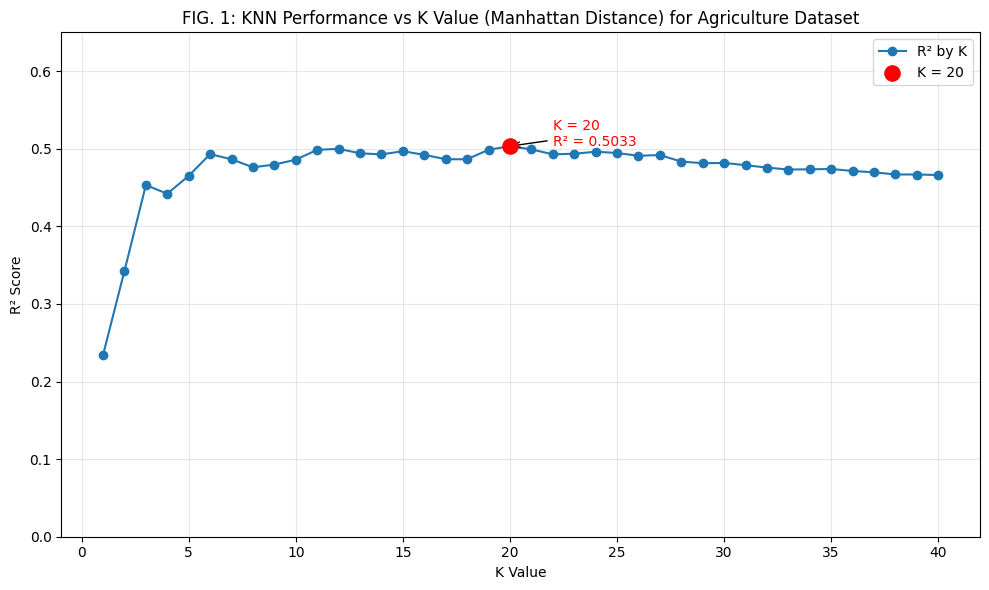

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ============================================================================
# PREPARE DATA
# ============================================================================

# Separate features and target
X = df_usa_agr_numeric.drop("Crop Yield (MT per HA)", axis=1)
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# TEST DIFFERENT DISTANCE METRICS
# ============================================================================

metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
n_neighbors = 5

results = {}

for metric in metrics:
    print(f"\n{'='*60}")
    print(f"Testing with {metric.upper()} distance")
    print(f"{'='*60}")
    
    # Create and train KNN model
    knn = KNeighborsRegressor(n_neighbors=n_neighbors, metric=metric)
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = knn.predict(X_test_scaled)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[metric] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}
    
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

# ============================================================================
# COMPARE RESULTS
# ============================================================================

print(f"\n{'='*60}")
print("SUMMARY: Performance by Distance Metric")
print(f"{'='*60}")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)

print(results_df.to_string())
print("\nNote: Higher R² is better. Lower RMSE/MAE/MSE is better.")

# ============================================================================
# TUNE K VALUE
# ============================================================================

print(f"\n{'='*60}")
print("Testing different K values with Euclidean distance")
print(f"{'='*60}")

k_values = range(1, 41)
k_results = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, metric='manhattan')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    k_results[k] = r2

best_k = max(k_results, key=k_results.get)
print(f"Best K: {best_k} with R²: {k_results[best_k]:.4f}")

# Visualize K values

plt.figure(figsize=(10, 6))

plt.plot(k_results.keys(), k_results.values(), marker='o', label='R² by K')

k_highlight = 20
r2_highlight = k_results[k_highlight]

plt.scatter(
    k_highlight,
    r2_highlight,
    color='red',
    s=120,
    zorder=5,
    label=f'K = {k_highlight}'
)

plt.annotate(
    f'K = {k_highlight}\nR² = {r2_highlight:.4f}',
    xy=(k_highlight, r2_highlight),
    xytext=(k_highlight + 2, r2_highlight),
    arrowprops=dict(facecolor='red', arrowstyle='->'),
    fontsize=10,
    color='red'
)

plt.xlabel('K Value')
plt.ylabel('R² Score')
plt.ylim(0.0,0.65)
plt.title('FIG. 1: KNN Performance vs K Value (Manhattan Distance) for Agriculture Dataset')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Testing with EUCLIDEAN distance
MSE:  0.0020
RMSE: 0.0451
MAE:  0.0090
R²:   0.5982

Testing with MANHATTAN distance
MSE:  0.0020
RMSE: 0.0448
MAE:  0.0081
R²:   0.6022

Testing with MINKOWSKI distance
MSE:  0.0020
RMSE: 0.0451
MAE:  0.0090
R²:   0.5982

Testing with COSINE distance
MSE:  0.0011
RMSE: 0.0325
MAE:  0.0092
R²:   0.7914

SUMMARY: Performance by Distance Metric
                MSE      RMSE       MAE        R²
cosine     0.001054  0.032460  0.009160  0.791421
manhattan  0.002010  0.044829  0.008131  0.602163
euclidean  0.002030  0.045051  0.008990  0.598219
minkowski  0.002030  0.045051  0.008990  0.598219

Note: Higher R² is better. Lower RMSE/MAE/MSE is better.

Testing different K values with Euclidean distance
Best K: 1 with R²: 0.7606


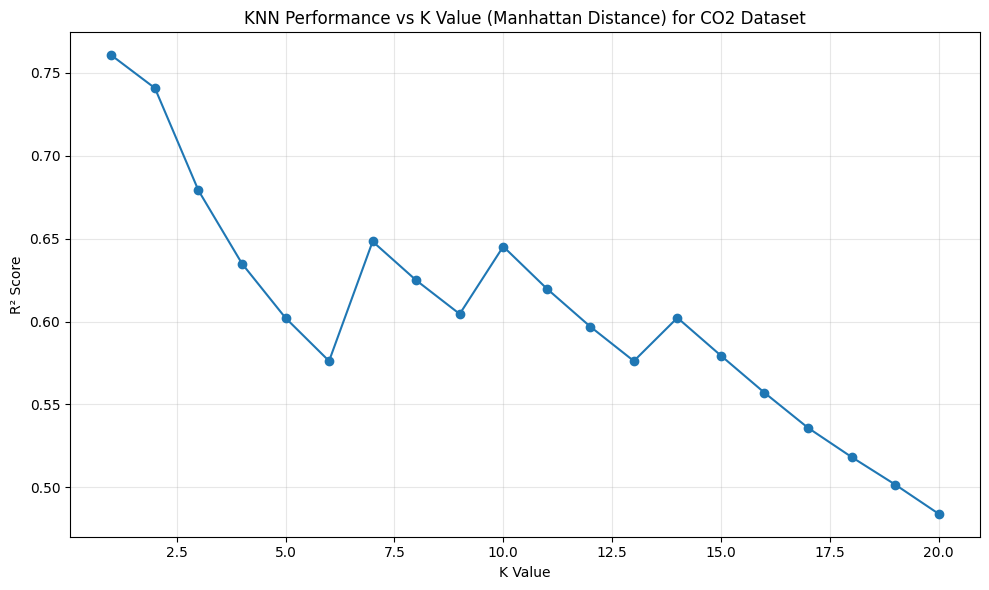

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ============================================================================
# PREPARE DATA
# ============================================================================

# Separate features and target
y1 = clean_numeric_dfCO2["temperature_change_from_co2"]
X1 = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Scale features (important for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# TEST DIFFERENT DISTANCE METRICS
# ============================================================================

metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
n_neighbors = 5

results = {}

for metric in metrics:
    print(f"\n{'='*60}")
    print(f"Testing with {metric.upper()} distance")
    print(f"{'='*60}")
    
    # Create and train KNN model
    knn = KNeighborsRegressor(n_neighbors=n_neighbors, metric=metric)
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = knn.predict(X_test_scaled)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[metric] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}
    
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

# ============================================================================
# COMPARE RESULTS
# ============================================================================

print(f"\n{'='*60}")
print("SUMMARY: Performance by Distance Metric")
print(f"{'='*60}")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)

print(results_df.to_string())
print("\nNote: Higher R² is better. Lower RMSE/MAE/MSE is better.")

# ============================================================================
# TUNE K VALUE
# ============================================================================

print(f"\n{'='*60}")
print("Testing different K values with Euclidean distance")
print(f"{'='*60}")

k_values = range(1, 21)
k_results = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, metric='manhattan')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    k_results[k] = r2

best_k = max(k_results, key=k_results.get)
print(f"Best K: {best_k} with R²: {k_results[best_k]:.4f}")

# Visualize K values
plt.figure(figsize=(10, 6))
plt.plot(k_results.keys(), k_results.values(), marker='o')
plt.xlabel('K Value')
plt.ylabel('R² Score')
plt.title('KNN Performance vs K Value (Manhattan Distance) for CO2 Dataset')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In this dataset, K=1 is the best K for KNN. There are also minimal calues for MSE and RMSE. I beleive that this is a sign of overfitting for the CO2 dataset. KNN may not be the best model to use for this dataset. 